# Tree-Based Models — Flight Delay Prediction
## Miami International Airport (MIA) | January–February 2024

This notebook builds two classification models to predict whether a flight will experience a **significant delay**:

- Decision Tree Classifier — interpretable, rule-based model
- Random Forest Classifier — ensemble model with feature importance

Due to extreme class imbalance in cancellations, we redefined the problem to predict **flight delays (>15 minutes)**.

We also ensure no data leakage by excluding variables directly used to construct the target.

In [49]:
# =====================================================
#  IMPORTS
# =====================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


In [50]:
# =====================================================
# LOAD CLEANED DATA
# =====================================================
df = pd.read_csv('../data/processed/mia_flights_clean.csv')

df['fl_date'] = pd.to_datetime(df['fl_date'])

# Create departure hour
df['dep_hour'] = (df['dep_time'] // 100).fillna(-1).astype(int)

print(f"Shape: {df.shape}")
df.head()

Shape: (19396, 19)


,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay,dep_hour
0,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,1758.0,34.0,1832.0,2012.0,7.0,0,100.0,700,0,0,17
1,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,2042.0,16.0,2058.0,2227.0,6.0,0,89.0,594,0,87,20
2,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,840.0,20.0,900.0,1030.0,10.0,0,90.0,594,0,0,8
3,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,2111.0,17.0,2128.0,12.0,6.0,0,164.0,1258,0,0,21
4,2024,1,1,1,2024-01-01,MIA,"Miami, FL",Florida,2159.0,28.0,2227.0,7.0,6.0,0,100.0,650,0,0,21


In [51]:
# =====================================================
# Delay target variable
# =====================================================
df['is_delayed'] = (df['late_aircraft_delay'] > 15).astype(int)

print("Class distribution:")
print(df['is_delayed'].value_counts())

print(f"\nDelay rate: {df['is_delayed'].mean():.2%}")

Class distribution:
is_delayed
0    17181
1     2215
Name: count, dtype: int64

Delay rate: 11.42%


In [52]:
# =====================================================
# Feature Selection
# =====================================================

FEATURES = [
    'month', 'day_of_week', 'dep_hour',
    'distance', 'taxi_out',
    'weather_delay'
]

TARGET = 'is_delayed'

model_df = df[FEATURES + [TARGET]].dropna()

X = model_df[FEATURES]
y = model_df[TARGET]

print("Final dataset shape:", model_df.shape)

Final dataset shape: (19191, 7)


In [53]:
# =====================================================
# Train / Test Split
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"Train delay rate: {y_train.mean():.2%}")
print(f"Test delay rate:  {y_test.mean():.2%}")


Train size: 15,352
Test size:  3,839
Train delay rate: 11.54%
Test delay rate:  11.54%


In [54]:
# =====================================================
# Decision Tree Model
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")
print(f"Train delay rate: {y_train.mean():.2%}")
print(f"Test delay rate:  {y_test.mean():.2%}")

Train size: 15,352
Test size:  3,839
Train delay rate: 11.54%
Test delay rate:  11.54%


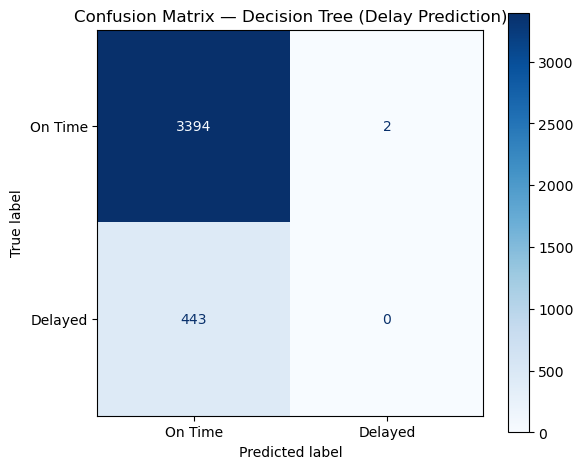

In [55]:
# =====================================================
# Confusion Matrix
# =====================================================
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['On Time', 'Delayed'],
    cmap='Blues',
    ax=ax
)

ax.set_title("Confusion Matrix — Decision Tree (Delay Prediction)")

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_dt_delay.png', dpi=150)
plt.show()

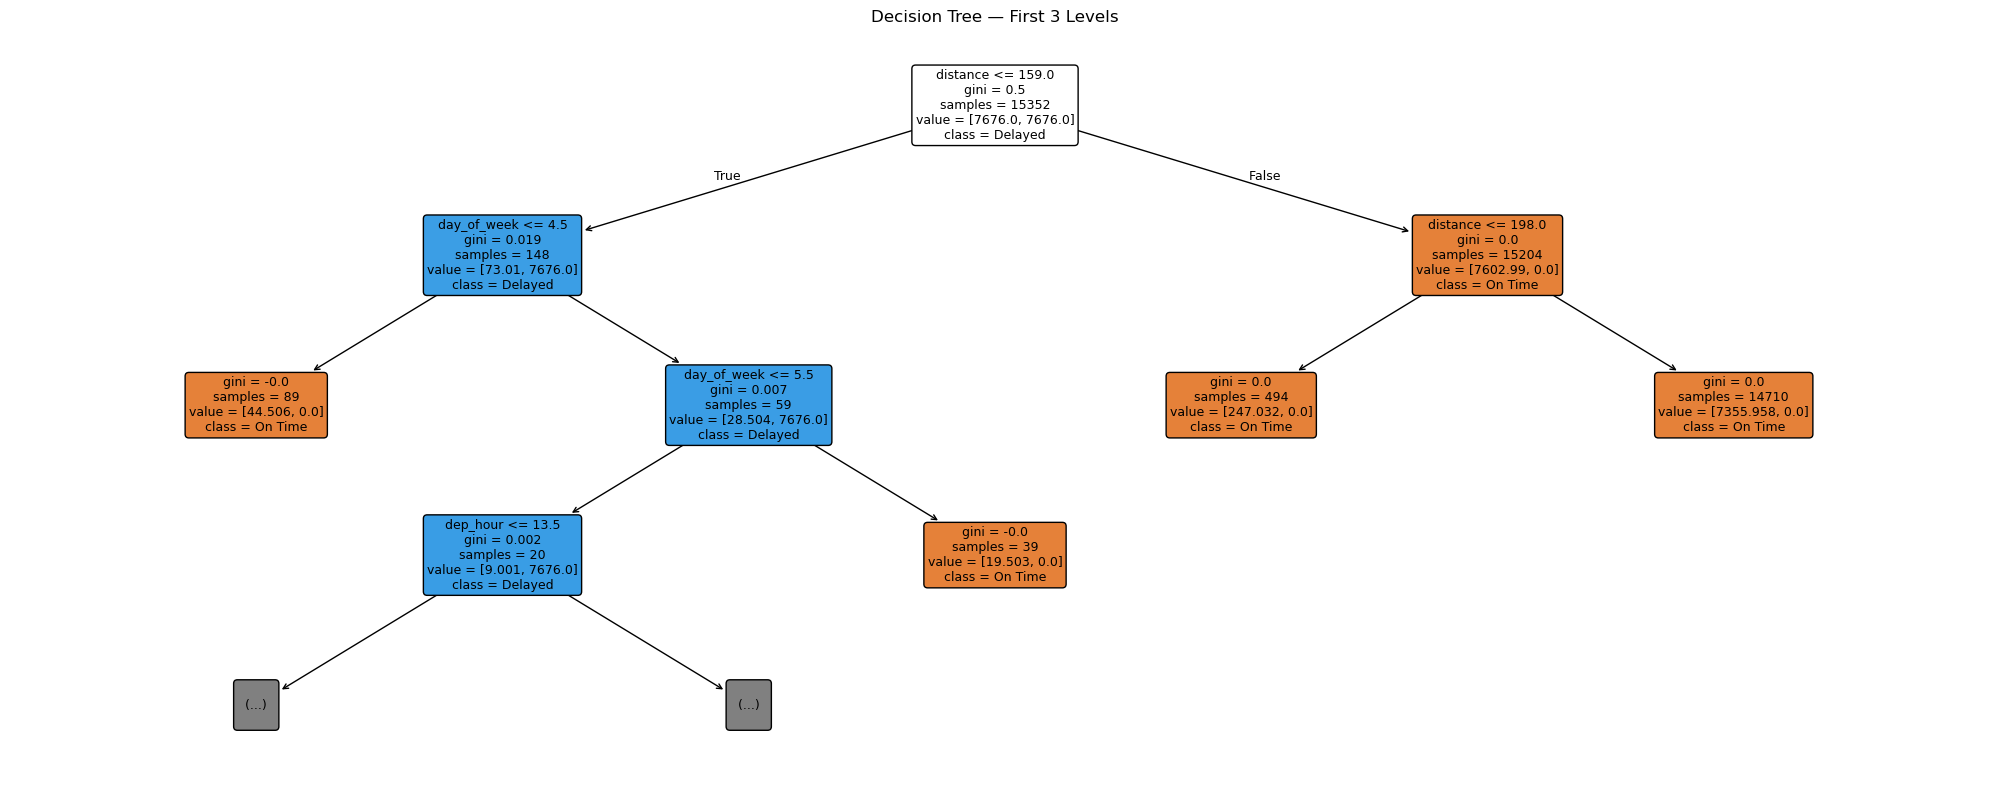

In [56]:
# =====================================================
# Tree Visualization
# =====================================================
fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    dt,
    max_depth=3,
    feature_names=FEATURES,
    class_names=['On Time', 'Delayed'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

ax.set_title("Decision Tree — First 3 Levels")

plt.tight_layout()
plt.savefig('../outputs/decision_tree_delay.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
# =====================================================
# Random Forest
# =====================================================
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest — Classification Report")
print("=" * 50)
print(classification_report(
    y_test, y_pred_rf,
    target_names=['On Time', 'Delayed']
))

Random Forest — Classification Report
              precision    recall  f1-score   support

     On Time       0.93      0.75      0.83      3396
     Delayed       0.23      0.56      0.32       443

    accuracy                           0.73      3839
   macro avg       0.58      0.65      0.58      3839
weighted avg       0.85      0.73      0.77      3839



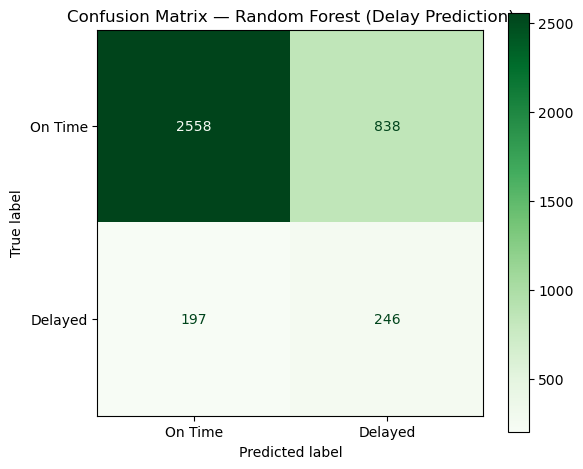

In [58]:
# =====================================================
#  Random forest - Confusion Matrix
# =====================================================
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['On Time', 'Delayed'],
    cmap='Greens',
    ax=ax
)

ax.set_title("Confusion Matrix — Random Forest (Delay Prediction)")

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_rf_delay.png', dpi=150)
plt.show()

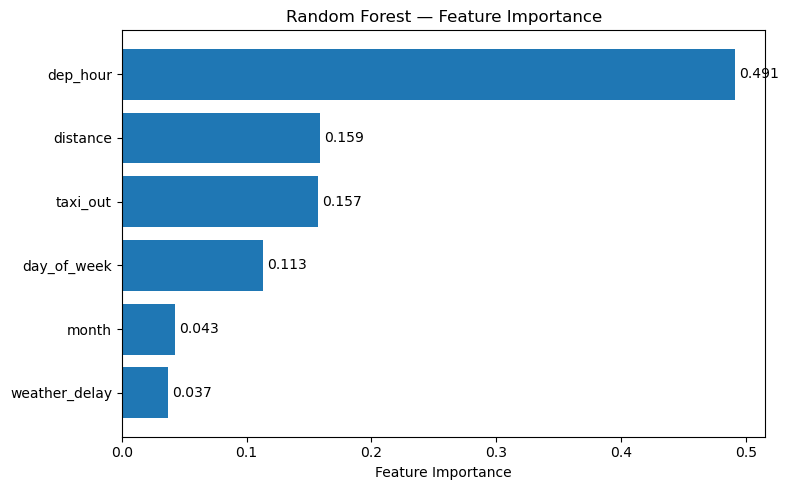

In [59]:
# =====================================================
# Feature Importance
# =====================================================
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    importance_df['feature'],
    importance_df['importance']
)

ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest — Feature Importance")

ax.bar_label(bars, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig('../outputs/feature_importance_delay.png', dpi=150)
plt.show()

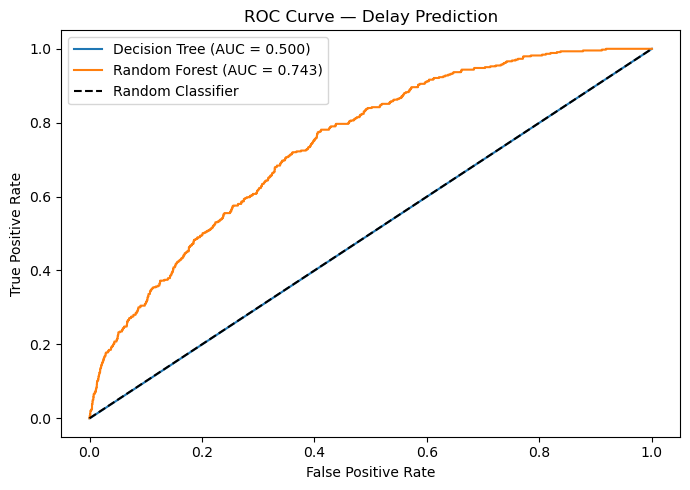

In [60]:
# =====================================================
# ROC Curves 
# =====================================================

auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Delay Prediction")

ax.legend()

plt.tight_layout()
plt.savefig('../outputs/roc_curve_delay.png', dpi=150)
plt.show()

In [61]:

# =====================================================
# Cross Validation
# =====================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_dt = cross_val_score(dt, X, y, cv=cv, scoring='roc_auc')
cv_rf = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

print("5-Fold Stratified Cross-Validation (ROC-AUC)")
print("=" * 50)
print(f"Decision Tree:  {cv_dt.mean():.4f} (+/- {cv_dt.std():.4f})")
print(f"Random Forest:  {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")

5-Fold Stratified Cross-Validation (ROC-AUC)
Decision Tree:  0.7527 (+/- 0.0163)
Random Forest:  0.7678 (+/- 0.0139)


In [62]:
# =====================================================
# Model Comparison Table
# =====================================================

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision (delayed)': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall (delayed)': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 (delayed)': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [auc_dt, auc_rf],
    'CV ROC-AUC': [cv_dt.mean(), cv_rf.mean()]
}).set_index('Model').round(4)

print("Model Comparison Summary")
print("=" * 60)
print(results)

results.to_csv('../outputs/tree_model_comparison_delay.csv')
print("\nSaved to outputs/tree_model_comparison_delay.csv")

Model Comparison Summary
               Accuracy  Precision (delayed)  Recall (delayed)  F1 (delayed)  \
Model                                                                          
Decision Tree    0.8841               0.0000            0.0000        0.0000   
Random Forest    0.7304               0.2269            0.5553        0.3222   

               ROC-AUC  CV ROC-AUC  
Model                               
Decision Tree   0.4997      0.7527  
Random Forest   0.7428      0.7678  

Saved to outputs/tree_model_comparison_delay.csv


## Final Insights — Flight Delay Prediction

### 1. Model Performance Comparison

The Random Forest model significantly outperformed the Decision Tree across most evaluation metrics.

- **Random Forest** achieved:
  - ROC-AUC: 0.7428 (Test) / 0.7678 (Cross-validation)
  - Recall (delayed flights): 55.5%
  - F1-score: 0.3222

- **Decision Tree** performed poorly:
  - ROC-AUC: ~0.50 (no better than random guessing)
  - Recall: 0.0 (failed to identify delayed flights)

This indicates that the Decision Tree model was too simple and likely underfitted the data.

---

### 2. Class Imbalance Impact

Although the dataset is more balanced than cancellations, delayed flights still represent only ~11% of the data.

- The Decision Tree model struggled with this imbalance and predicted mostly the majority class (on-time flights).
- The Random Forest handled the imbalance better using `class_weight='balanced'`, improving recall for delayed flights.

---

### 3. Trade-off Between Precision and Recall

The Random Forest model shows:

- **Recall (55.5%)** → It successfully identifies more than half of delayed flights.
- **Precision (22.7%)** → Many predicted delays are false positives.

This trade-off is expected in imbalanced classification problems and may be acceptable depending on business goals.

---

### 4. Model Stability (Cross-Validation)

Cross-validation results show:

- Random Forest is stable and consistent (CV ROC-AUC ≈ 0.77)
- Decision Tree shows high variance and unreliable performance

This confirms that ensemble methods generalize better for this type of problem.

---

### 5. Business Interpretation

From an operational perspective:

- The model can help **flag flights with higher delay risk**, even if not perfectly accurate.
- A higher recall is valuable, as missing a delay can be more costly than a false alarm.
- The Random Forest model could be used as a **decision-support tool** for airport operations.

---

### 6. Key Takeaways

- Predicting cancellations was not feasible due to extreme imbalance.
- Reframing the problem to **delay prediction** enabled meaningful modeling.
- Ensemble models (Random Forest) are more effective than single models (Decision Tree).
- Further improvements could include:
  - More features (airline, destination, weather conditions)
  - Hyperparameter tuning
  - Advanced models (e.g., Gradient Boosting)

---